# Churn Dataset

- **Problem Type**: Classification
- **Evaluation Metric**: Recall
- **Models to test**:
  - Machine Learning
    - Logistic Regression (Base Model - If other models can't beat this then it's useless to use anything else because of higher inference cost)
    - Decision Tree Classifier
    - Random Forest Classifier
  - Boosting
    - XGBoost Classifier
    - LightGBM Classifier
  - Deep Learning
    - Artificial Neural Network

## Loading Libraries

In [1]:
import os

os.environ['KERAS_BACKEND'] = 'torch'

import time

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import chi2

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.utils import class_weight

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [ ]:
df_og = pd.read_csv("heart_2020_cleaned.csv")
df_og.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


## Basic Info on Dataset

### Check for the shape of our dataframe

In [3]:
df_og.shape

(319795, 18)

Our dataset contains 18 features and each having ~3,20,000 enteries making it sufficient for ANN.

### Check each column's data type

In [4]:
df_og.info()

<class 'pandas.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  str    
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  str    
 3   AlcoholDrinking   319795 non-null  str    
 4   Stroke            319795 non-null  str    
 5   PhysicalHealth    319795 non-null  int64  
 6   MentalHealth      319795 non-null  int64  
 7   DiffWalking       319795 non-null  str    
 8   Sex               319795 non-null  str    
 9   AgeCategory       319795 non-null  str    
 10  Race              319795 non-null  str    
 11  Diabetic          319795 non-null  str    
 12  PhysicalActivity  319795 non-null  str    
 13  GenHealth         319795 non-null  str    
 14  SleepTime         319795 non-null  int64  
 15  Asthma            319795 non-null  str    
 16  KidneyDisease     319795 non-nu

We have
- 4 numerical columns
- 14 categorical columns

Our target variable is HeartDisease and is categorical column

| S. No. | Original Variable / Attribute | Coded Variable / Attribute | Interpretation                                                                                                                         |
| ------ | ----------------------------- | -------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| 1      | CVDINFR4                      | HeartDisease               | Those who have ever had CHD or myocardial infarction                                                                                   |
| 2      | \_BMI5CAT                     | BMI                        | Body Mass Index                                                                                                                        |
| 3      | \_SMOKER3                     | Smoking                    | Have you ever smoked more than 100 cigarettes in your life? (Yes or No)                                                                |
| 4      | \_RFDRHV7                     | AlcoholDrinking            | Adult men who drink more than 14 drinks per week and adult women who consume more than 7 drinks per week are considered heavy drinkers |
| 5      | CVDSTRK3                      | Stroke                     | (Ever told) (you had) a stroke?                                                                                                        |
| 6      | PHYSHLTH                      | PhysicalHealth             | Physical illness and injury during the past 30 days                                                                                    |
| 7      | MENTHLTH                      | MentalHealth               | Number of days in the last 30 days with poor mental health                                                                             |
| 8      | DIFFWALK                      | DiffWalking                | Are you having trouble walking or climbing stairs?                                                                                     |
| 9      | SEXVAR                        | Sex                        | Are you male or female?                                                                                                                |
| 10     | \_AGE_G                       | AgeCategory                | Age group category (from fourteen predefined groups)                                                                                   |
| 11     | \_IMPRACE                     | Race                       | Imputed race/ethnicity value                                                                                                           |
| 12     | DIABETE4                      | Diabetic                   | (Ever told) (you had) diabetes?                                                                                                        |
| 13     | EXERANY2                      | PhysicalActivity           | Adults who engaged in physical activity or exercise outside regular work in the past 30 days                                           |
| 14     | GENHLTH                       | GenHealth                  | Self-reported overall health rating                                                                                                    |
| 15     | SLEPTIM1                      | SleepTime                  | Average number of hours of sleep in a 24-hour period                                                                                   |
| 16     | CHASTHMA                      | Asthma                     | (Ever told) (you had) asthma?                                                                                                          |
| 17     | CHCKDNY2                      | KidneyDisease              | Ever told you had kidney disease (excluding stones, bladder infection, or incontinence)?                                               |
| 18     | CHCSCNCR                      | SkinCancer                 | Ever told (you had) skin cancer?                                                                                                       |


### Check for Null Values

In [5]:
df_og.isna().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

There is no null values in our dataset.

## Stastical Inference

In [6]:
df_og.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


#### Conclusion

- **BMI**: 50% of the dataset has a BMI between 24.03 and 31.42, indicating that the majority of individuals fall into the overweight or obese clinical categories.
- **Physical Health**: 75% of respondents reported 2 or fewer days of poor physical health per month. The maximum value of 30 represents individuals experiencing chronic illness or pain for the entire month, which is a valid clinical state and not a data entry error.
- **Mental Health**: 50% of respondents reported 0 days of poor mental health. Cases reporting 30/30 days are clinically representative of severe, chronic depression or anxiety, meaning these high values are critical signals rather than outliers.
- **Sleep Time**: 50% of the dataset reports a healthy sleep duration of 6 to 8 hours. Extreme values like 1 hour or 24 hours exist; while they represent statistical outliers outside the interquartile range, they may reflect severe biological edge cases (e.g., extreme insomnia or hypersomnia) or self-reporting survey errors.

## Visualisation

In [7]:
def eda_plots(df, target=None):
    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()
    numerical_cols = df.select_dtypes(include="number").columns.tolist()

    if target:
        if target in categorical_cols:
            categorical_cols.remove(target)
            target_type = "categorical"
        elif target in numerical_cols:
            numerical_cols.remove(target)
            target_type = "numerical"
        else:
            raise ValueError(f"Target '{target}' not found in dataframe.")

    print("=" * 50)
    print("UNIVARIATE ANALYSIS")
    print("=" * 50)

    if numerical_cols:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(numerical_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
            axes[i].axvline(
                df[col].mean(), color="r", linestyle="dashed", linewidth=1.5
            )
            axes[i].set_title(f"Distribution: {col}")

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if numerical_cols:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(numerical_cols):
            axes[i].boxplot(df[col].dropna())
            axes[i].set_title(col)

        # Remove unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if categorical_cols:
        n_cols = 3
        n_rows = math.ceil(len(categorical_cols) / n_cols)
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
        )
        axes = axes.flatten()

        for i, col in enumerate(categorical_cols):
            val_counts = df[col].value_counts()
            if len(val_counts) > 5:
                top = val_counts.head(5)
                top["Others"] = val_counts[5:].sum()
            else:
                top = val_counts

            axes[i].pie(top, labels=top.index, autopct="%1.1f%%", startangle=140)
            axes[i].set_title(f"Distribution: {col}")

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    if target:
        print("\n" + "=" * 50)
        print("🔹 BIVARIATE ANALYSIS (Feature vs Target)")
        print("=" * 50)

        if numerical_cols:
            n_cols = 3
            n_rows = math.ceil(len(numerical_cols) / n_cols)
            fig, axes = plt.subplots(
                n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
            )
            axes = axes.flatten()

            for i, col in enumerate(numerical_cols):
                if target_type == "categorical":
                    sns.boxplot(data=df, x=target, y=col, ax=axes[i])
                else:
                    sns.scatterplot(data=df, x=col, y=target, alpha=0.5, ax=axes[i])
                axes[i].set_title(f"{col} vs {target}")

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()

        if categorical_cols:
            n_cols = 3
            n_rows = math.ceil(len(categorical_cols) / n_cols)
            fig, axes = plt.subplots(
                n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False
            )
            axes = axes.flatten()

            for i, col in enumerate(categorical_cols):
                if target_type == "categorical":
                    sns.countplot(data=df, x=col, hue=target, ax=axes[i])
                else:
                    sns.boxplot(data=df, x=col, y=target, ax=axes[i])
                axes[i].tick_params(axis="x", rotation=45)
                axes[i].set_title(f"{col} vs {target}")

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()

    print("\n" + "=" * 50)
    print("🔹 MULTIVARIATE ANALYSIS")
    print("=" * 50)

    num_df = df.select_dtypes(include=["number"])
    if num_df.shape[1] > 1:
        plt.figure(figsize=(10, 8))
        corr = num_df.corr()
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Correlation Heatmap")
        plt.show()

    sns.pairplot(df[numerical_cols].dropna(), corner=True)

    plt.suptitle("Pairplot", y=1.02)
    plt.show()

UNIVARIATE ANALYSIS


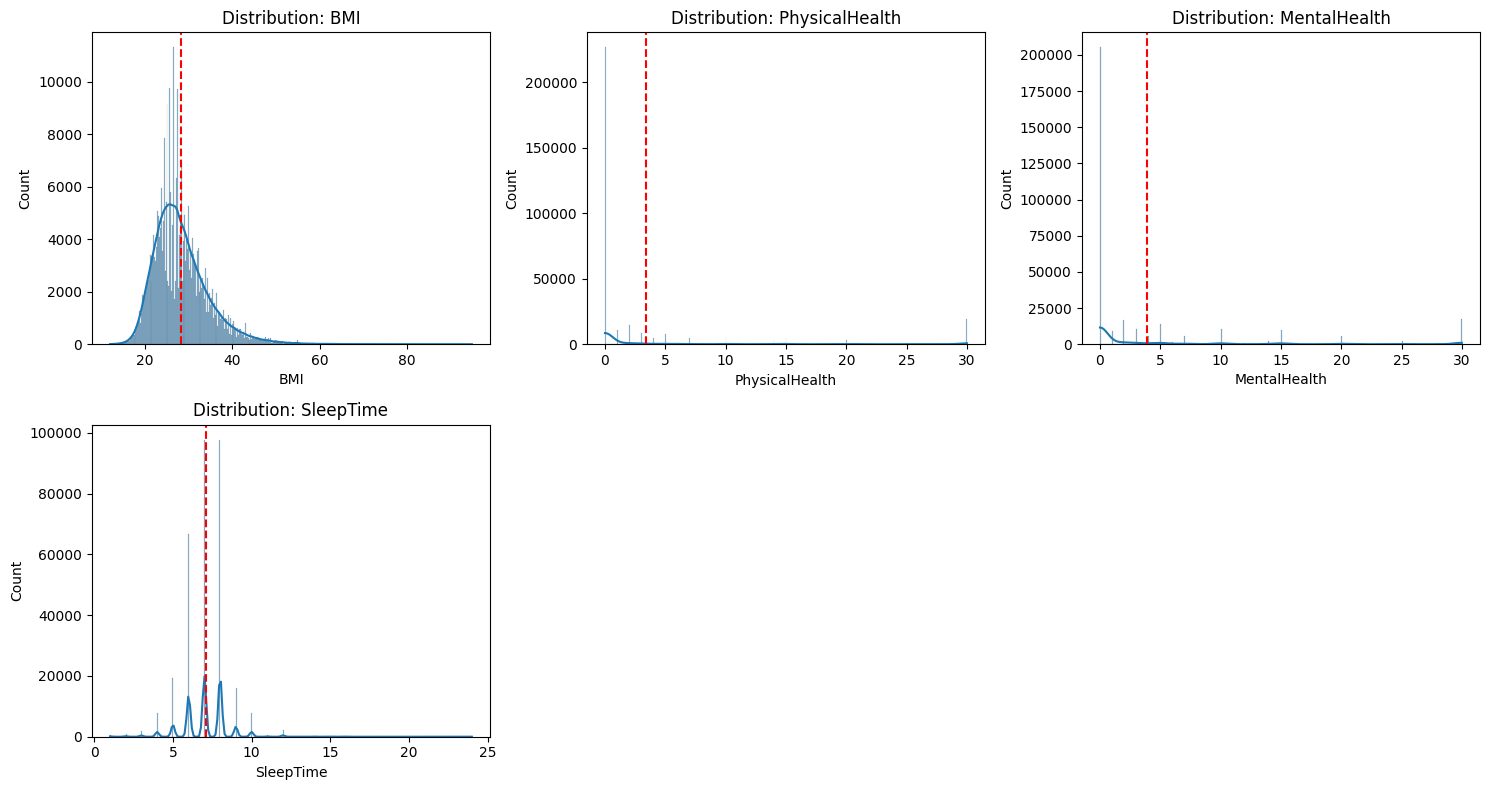

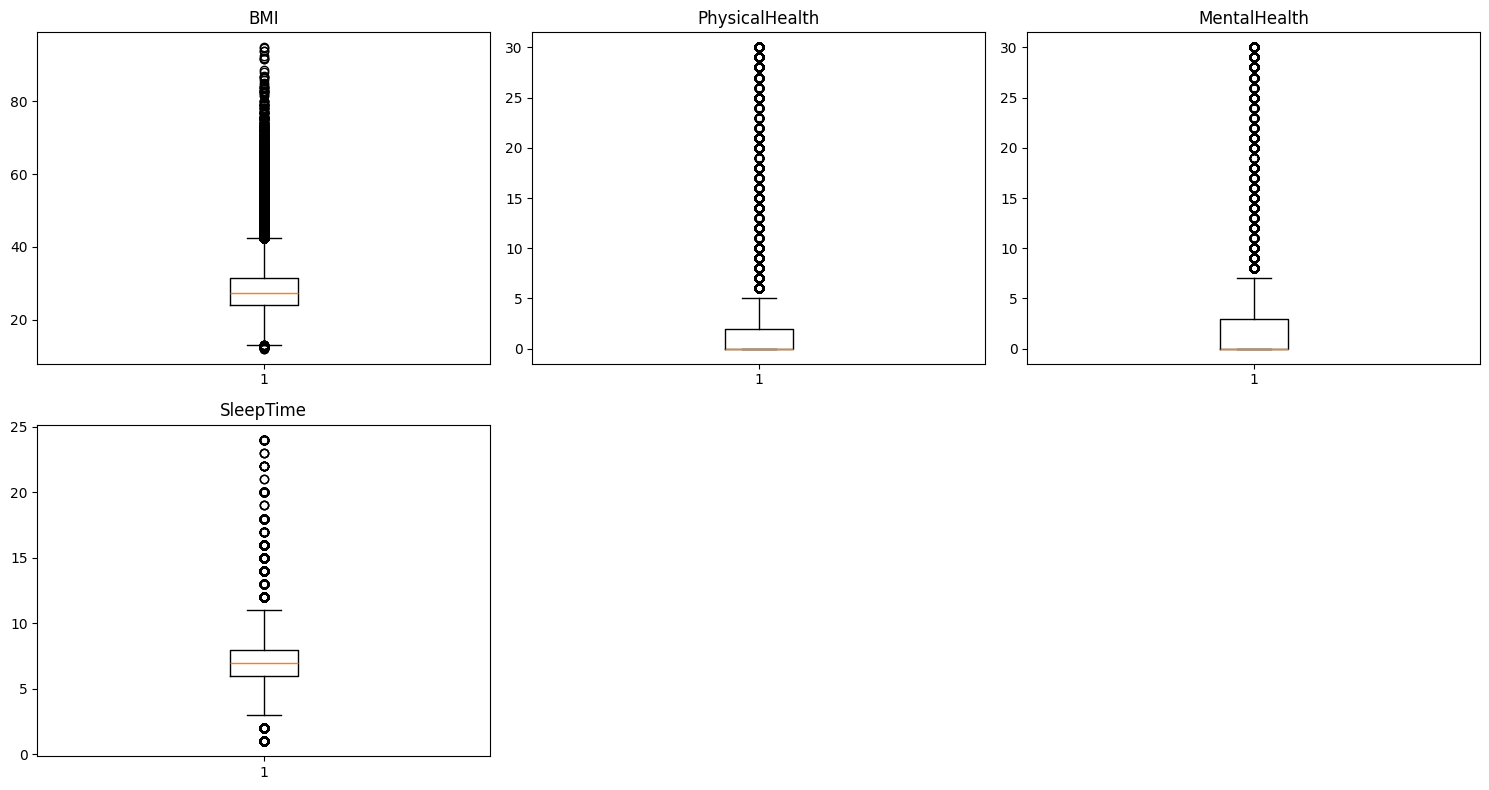

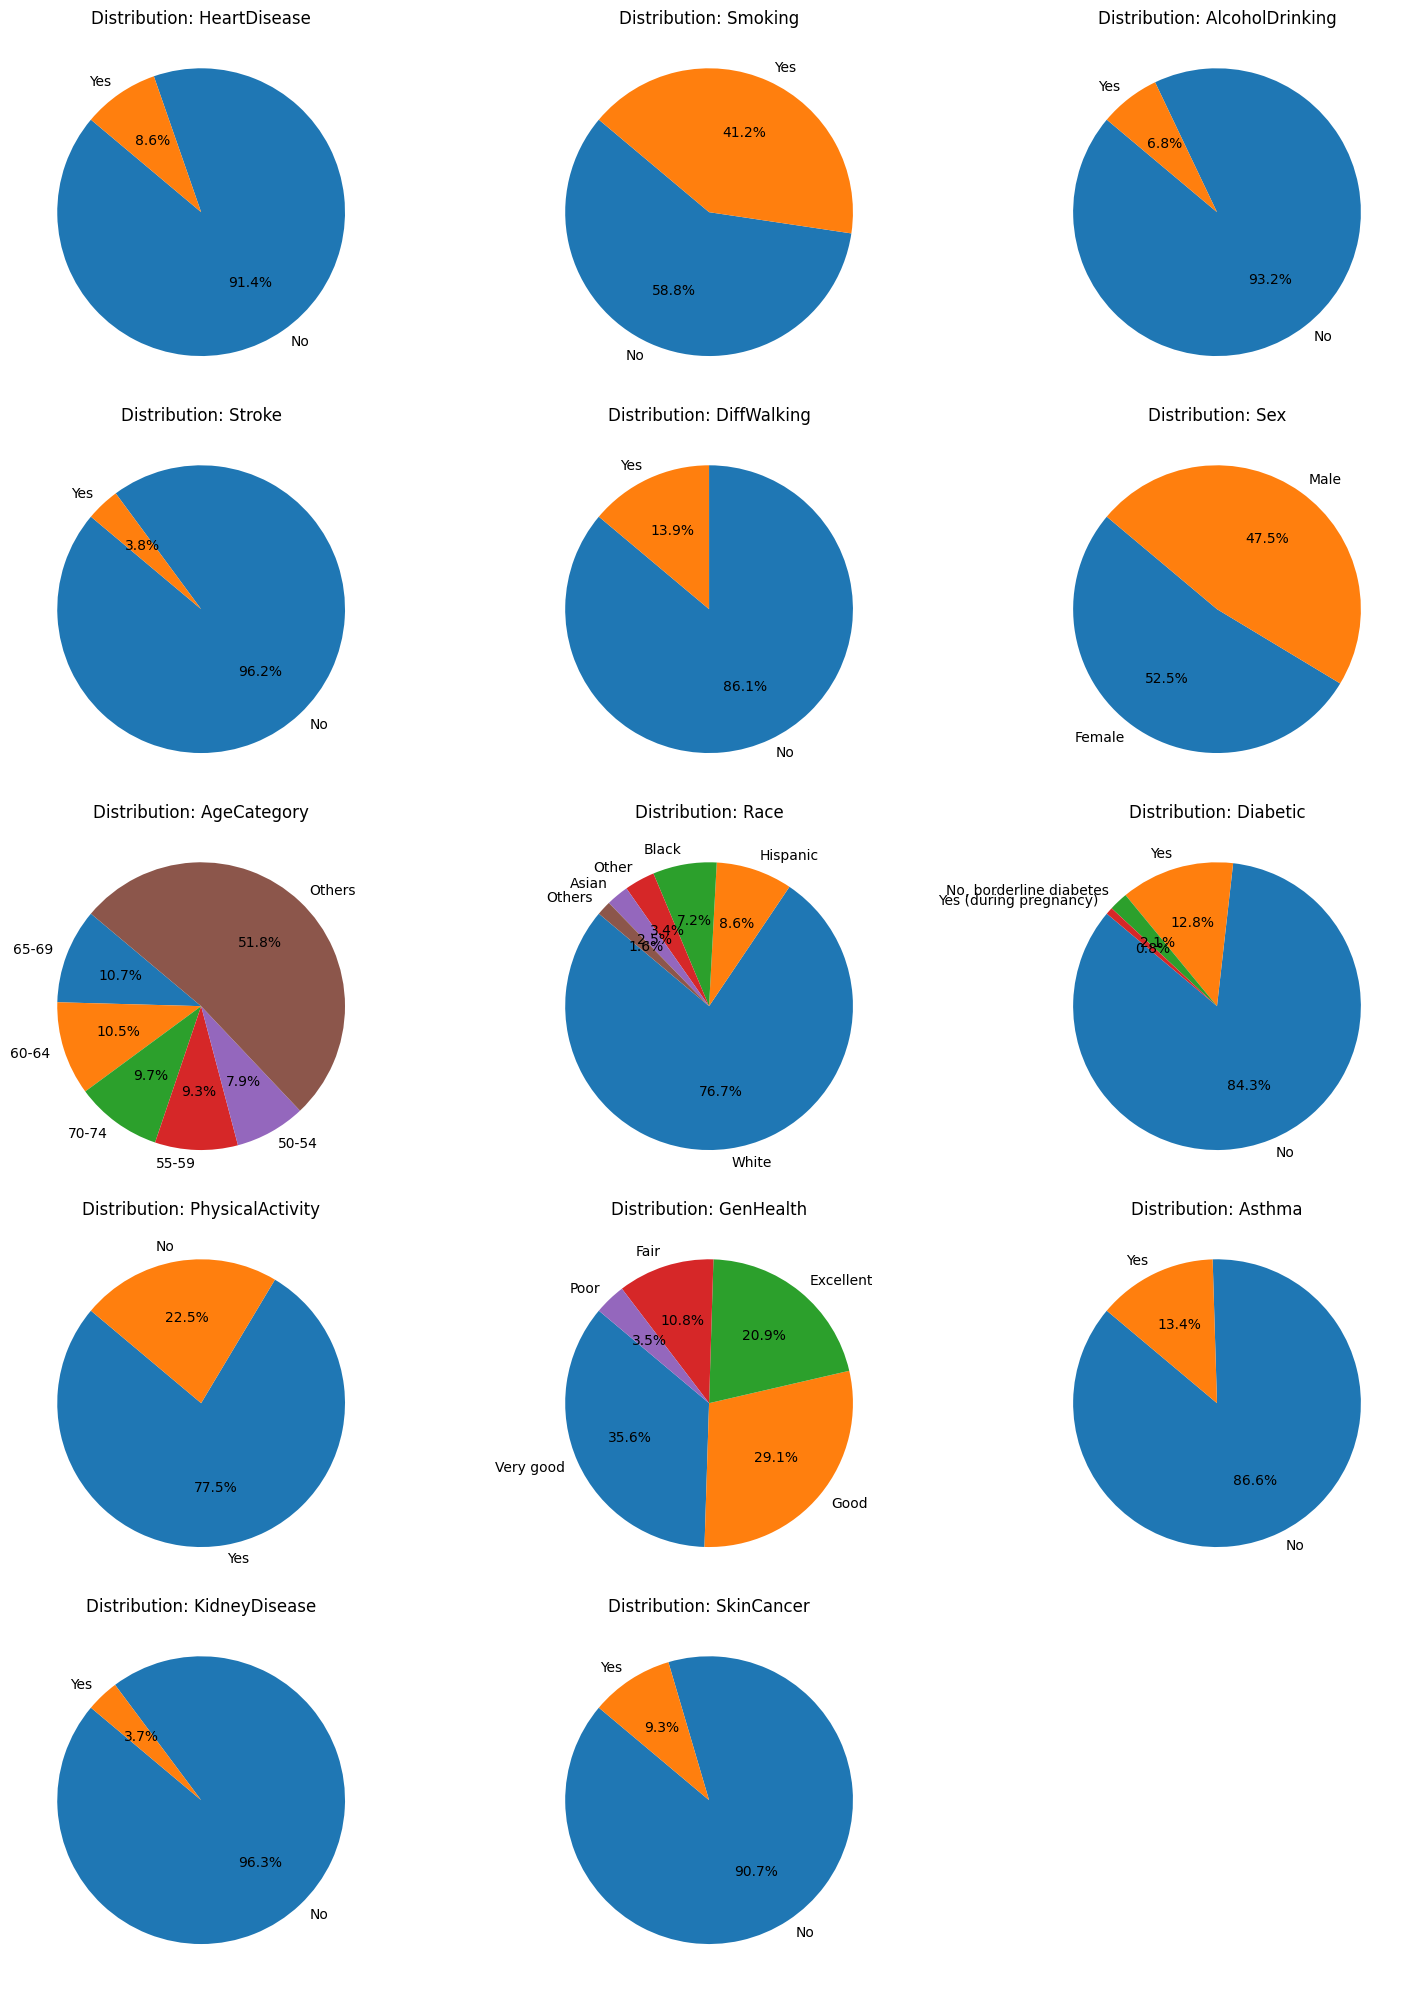


🔹 MULTIVARIATE ANALYSIS


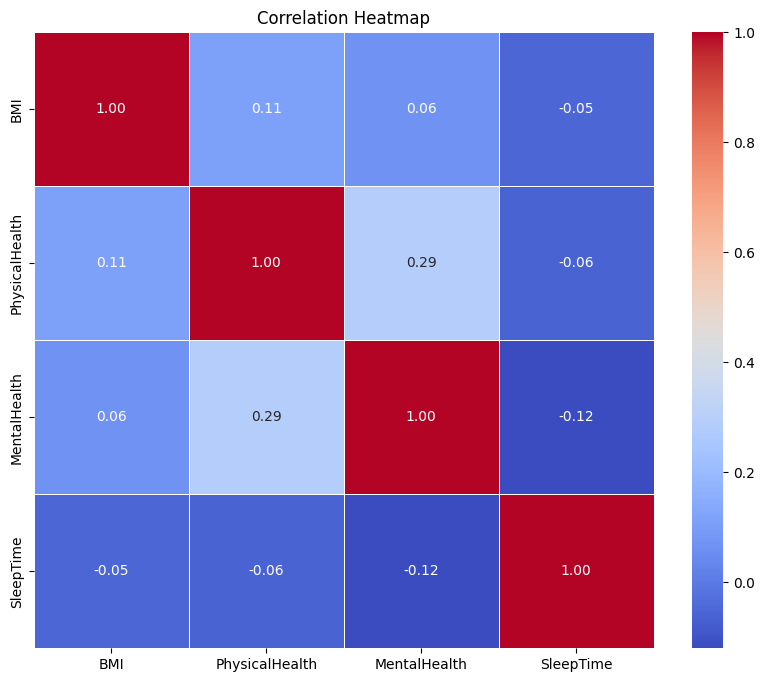

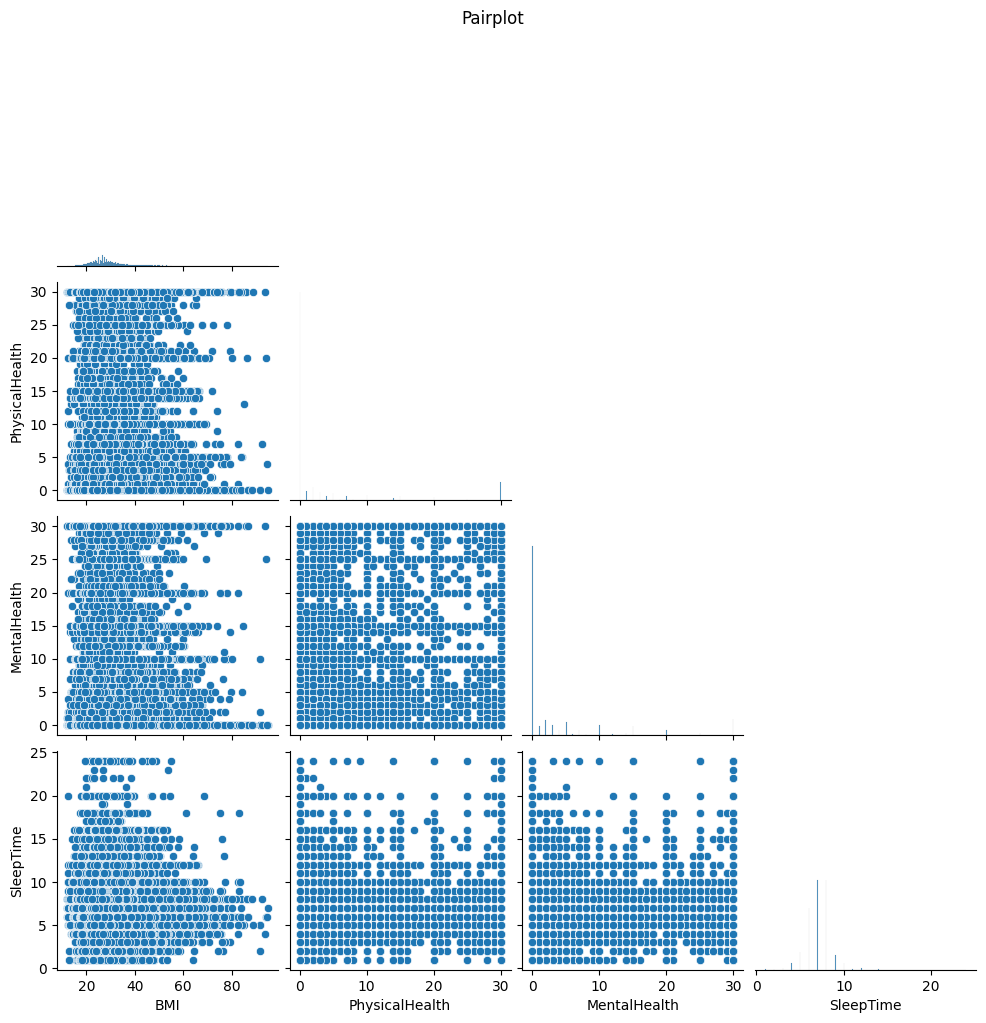

In [8]:
target = "HeartDisease"
eda_plots(df_og)

### Conclusion:

#### Univariate Analysis

- **Target Variable Imbalance:** The `HeartDisease` target is heavily imbalanced, with only 8.6% of the dataset representing positive cases. This confirms the need for stratified splitting and robust evaluation metrics like PR-AUC and Macro F1-Score.
- **BMI:** 50% of the dataset has a BMI between 24.03 and 31.42, indicating that the majority of individuals fall into the overweight or obese clinical categories. The distribution is heavily right-skewed with extreme high-end outliers.
- **Physical & Mental Health:** Both distributions are highly zero-inflated (most people report 0 poor health days). However, the visible spikes at 30 days are clinically representative of severe, chronic conditions (e.g., chronic pain or clinical depression) rather than data entry errors.
- **Sleep Time:** The vast majority of respondents report a healthy sleep duration of 6 to 8 hours. Extreme values (1 hour or 24 hours) exist as statistical outliers, likely representing severe biological edge cases or self-reporting errors.
- **Categorical Demographics & Lifestyle:** The dataset is predominantly White (76.7%). A significant portion of the population engages in risky lifestyle factors, with 41.2% identifying as smokers, though heavy alcohol consumption is low (6.8%).
- **Pre-existing Conditions:** Serious comorbidities are relatively rare but present, including Diabetic (12.8%), Asthma (13.4%), Skin Cancer (9.3%), Stroke (3.8%), and Kidney Disease (3.7%).

#### Multivariate Analysis

- **Lack of Strong Linear Relationships:** The correlation heatmap reveals that there are no strong linear correlations between any of the continuous numerical features. 
- **Physical and Mental Health Overlap:** The highest observed correlation is a weak positive relationship (0.29) between `PhysicalHealth` and `MentalHealth`. This suggests a slight tendency that individuals experiencing chronic physical ailments also report higher days of poor mental health.
- **Feature Independence:** `SleepTime` and `BMI` show practically zero correlation (values ranging from -0.12 to 0.11) with the other numerical features. 
- **Pairplot Distributions:** The pairplot confirms the lack of linear relationships. The blocky, grid-like scatter plots are a result of the features being discrete integer values (e.g., exact hours of sleep, exact days of poor health), showing that complex, non-linear models (like Random Forests or ANNs) will be necessary to find multidimensional decision boundaries.

## Target Variable Analysis - HeartDisease

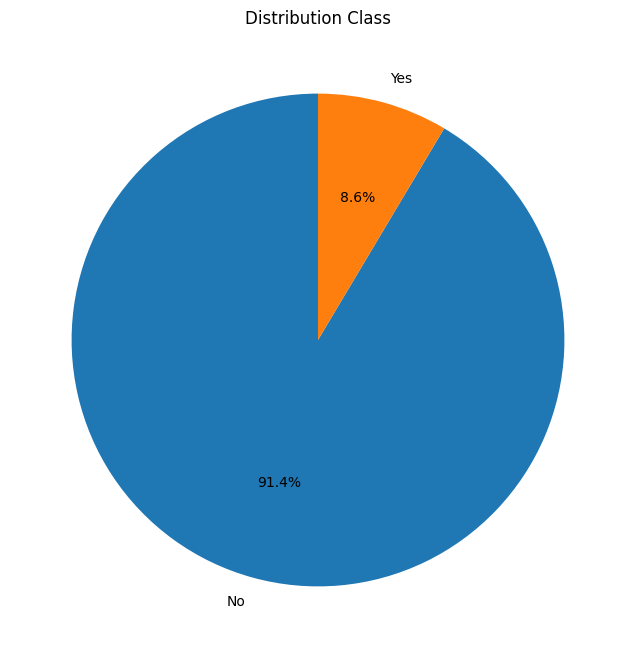

In [9]:
values = df_og[target].value_counts()
plt.figure(figsize=(8, 8))
plt.title("Distribution Class")
plt.pie(values, autopct="%1.1f%%", startangle=90, labels=values.index)
plt.show()

Our target feature isn't well distributed so we will use `stratify = y` during training and testing split.

## Feature Selection

### Make a copy of the Data

In [10]:
df = df_og.copy(deep=True)

### VIF for numerical column

In [11]:
num_cols = df.select_dtypes(include='number').columns
X_num = df[num_cols]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_num.values, i) for i in range(len(X_num.columns))
]
print(vif_data)

          Feature        VIF
0             BMI  11.737985
1  PhysicalHealth   1.299151
2    MentalHealth   1.351695
3       SleepTime  11.186991


### Chi-Square test for categorical column

In [12]:
X_cat = df.select_dtypes(include=["object"]).drop(
    columns=target, errors="ignore"
)
le = LabelEncoder()

X_cat_encoded = X_cat.apply(le.fit_transform)
y_encoded = le.fit_transform(df[target])

# Calculate Chi-Square scores
chi_scores = chi2(X_cat_encoded, y_encoded)

# Save it in a dataframe
chi_results = pd.DataFrame(
    {"Feature": X_cat.columns, "Chi2 Score": chi_scores[0], "P-Value": chi_scores[1]}
)

# Sort by P-Value (Lowest P-Value = Most Important)
chi_results = chi_results.sort_values(by="P-Value", ascending=True)

# Format the float output to 6 decimal places
pd.options.display.float_format = "{:.6f}".format

# A logic column to see what to drop immediately
chi_results["Significant?"] = chi_results["P-Value"] < 0.05

chi_results

,Feature,Chi2 Score,P-Value,Significant?
0,Smoking,2181.953023,0.000000,True
2,Stroke,11922.577647,0.000000,True
3,DiffWalking,11154.414931,0.000000,True
5,AgeCategory,33991.390453,0.000000,True
7,Diabetic,15526.406399,0.000000,True
11,KidneyDisease,6493.654143,0.000000,True
12,SkinCancer,2525.122509,0.000000,True
4,Sex,823.195671,0.000000,True
8,PhysicalActivity,718.810142,0.000000,True
10,Asthma,475.647835,0.000000,True


### Feature Selection & Bivariate Analysis

#### 1. Multicollinearity Check (VIF)
A Variance Inflation Factor (VIF) analysis was conducted on the numerical features to check for multicollinearity. 
- **Results:** `PhysicalHealth` (1.30) and `MentalHealth` (1.35) show negligible collinearity. However, `BMI` (11.74) and `SleepTime` (11.19) exceeded the standard threshold of 10.
- **Interpretation & Action:** While a VIF > 10 typically indicates high multicollinearity, this is an artifact of calculating uncentered VIF on strictly positive variables without an intercept constant. The earlier Correlation Heatmap proved `BMI` and `SleepTime` have near-zero correlation (-0.05). Therefore, no numerical features will be dropped, as there is no true collinear overlap.

#### 2. Categorical Feature Significance (Chi-Square Test)
A Chi-Square test for independence was executed against the target variable (`HeartDisease`) for all categorical features.
- **The "Large N" Effect:** Every single categorical feature returned a p-value of exactly 0.000000. In massive datasets ($N \approx 320,000$), even the most microscopic deviations from a perfectly uniform distribution are mathematically flagged as highly significant. 
- **Relative Predictive Power:** Because p-values hit the floating-point floor, we must look at the raw Chi-Square statistics to determine actual feature importance:
    - **Strongest Predictors:** `AgeCategory` (33,991) and `Diabetic` (15,526) have overwhelmingly high Chi-Square scores, making them the strongest biological and demographic indicators of heart disease risk in this dataset. `Stroke` and `DiffWalking` also show massive significance.
    - **Weakest Predictors:** `GenHealth` (41) and `Race` (129) have the lowest scores. While technically statistically significant due to the sample size, they offer the lowest relative predictive power.
- **Action:** Because all features passed the threshold for statistical significance, and tree-based/neural network models handle high dimensionality well, no categorical features will be dropped during this stage.

## Target Feature and Input split

In [13]:
X = df.drop(target, axis=1)
y = df[target]

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (319795, 17)
y Shape: (319795,)


In [14]:
LE = LabelEncoder()
y = LE.fit_transform(y)

## Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42, test_size=0.2
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (255836, 17)
X_test shape: (63959, 17)
y_train shape: (255836,)
y_test shape: (63959,)


## Feature Engineering

In [16]:
class HealthFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()

        symptom_cols = ["Stroke", "Diabetic", "Asthma", "KidneyDisease", "SkinCancer"]
        X_out["Symptom_Count"] = (X_out[symptom_cols] == "Yes").sum(axis=1)

        high_risk = ["65-69", "70-74", "75-79", "80 or older"]
        X_out["High_Risk_Age"] = X_out["AgeCategory"].isin(high_risk).astype(int)

        return X_out

## Defining Preprocessors

In [17]:
num_cols = X_train.select_dtypes(include="number").columns.tolist() + [
    "Symptom_Count",
    "High_Risk_Age",
]
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

gen_health_order = ["Poor", "Fair", "Good", "Very good", "Excellent"]
age_order = [
    "18-24",
    "25-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-64",
    "65-69",
    "70-74",
    "75-79",
    "80 or older",
]

ordinal_cats = [
    (
        gen_health_order
        if col == "GenHealth"
        else age_order if col == "AgeCategory" else X_train[col].unique().tolist()
    )
    for col in cat_cols
]

# ---------------------------------------------------------
# PIPELINE 1: For Linear/Distance Models (LogReg, SVM, KNN)
# Strategy: StandardScaler + OneHotEncoder
# ---------------------------------------------------------
linear_preprocessor = Pipeline(
    steps=[
        ("engineer", HealthFeatureEngineer()),
        (
            "col_trans",
            ColumnTransformer(
                transformers=[
                    ("num", StandardScaler(), num_cols),
                    (
                        "cat",
                        OneHotEncoder(drop="first", handle_unknown="ignore"),
                        cat_cols,
                    ),
                ],
                remainder="passthrough",
            ),
        ),
    ]
)

# ---------------------------------------------------------
# PIPELINE 2: For Tree-Based Models (RF, XGB, LGBM, DT)
# Strategy: No Scaling (Passthrough) + OrdinalEncoder
# ---------------------------------------------------------
tree_preprocessor = Pipeline(
    steps=[
        ("engineer", HealthFeatureEngineer()),
        (
            "col_trans",
            ColumnTransformer(
                transformers=[
                    ("num", "passthrough", num_cols),
                    (
                        "cat",
                        OrdinalEncoder(
                            categories=ordinal_cats,
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                        cat_cols,
                    ),
                ],
                remainder="passthrough",
            ),
        ),
    ]
)

# ---------------------------------------------------------
# PIPELINE 3: For Neural Networks
# Strategy: MinMaxScaler + OneHotEncoder
# ---------------------------------------------------------
nn_preprocessor = Pipeline(
    steps=[
        ("engineer", HealthFeatureEngineer()),
        (
            "col_trans",
            ColumnTransformer(
                transformers=[
                    ("num", MinMaxScaler(), num_cols),
                    (
                        "cat",
                        OneHotEncoder(
                            drop="first", sparse_output=False, handle_unknown="ignore"
                        ),
                        cat_cols,
                    ),
                ],
                remainder="passthrough",
            ),
        ),
    ]
)

## Model Pipeline

In [18]:
models = {
    "Logistic Regression": Pipeline(
        [
            ("pre", linear_preprocessor),
            ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
        ]
    ),
    "Decision Tree": Pipeline(
        [
            ("pre", tree_preprocessor),
            ("clf", DecisionTreeClassifier(class_weight="balanced")),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("pre", tree_preprocessor),
            ("clf", RandomForestClassifier(class_weight="balanced")),
        ]
    ),
    "XGBoost": Pipeline(
        [
            ("pre", tree_preprocessor),
            (
                "clf",
                XGBClassifier(
                    eval_metric="logloss",
                    tree_method="hist",
                    device="cuda",
                    scale_pos_weight=10,
                ),
            ),
        ]
    ),
    "LightGBM": Pipeline(
        [
            ("pre", tree_preprocessor),
            (
                "clf",
                LGBMClassifier(verbose=-1, device="gpu", class_weight="balanced"),
            ),
        ]
    ),
}

## Model Training

In [19]:
results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    recall = recall_score(y_test, y_pred)
    
    results_list.append({"Model": name, "Recall": recall})

    print(f"Training done for {name}")

ML_Results = pd.DataFrame(results_list).sort_values(by="Recall", ascending=False)

ML_Results

Training done for Logistic Regression
Training done for Decision Tree
Training done for Random Forest
Training done for XGBoost
Training done for LightGBM


,Model,Recall
4,LightGBM,0.802009
0,Logistic Regression,0.774612
3,XGBoost,0.754703
1,Decision Tree,0.232329
2,Random Forest,0.111598


As we can see, LightGBM performs the best here, so we will tune hyperparameters on that.

## Hyperparamter tuning for Logistic Regression

In [20]:
# Define the pipeline
lgbm_pipeline = models["LightGBM"]

# Define the hyperparameters dictionary
param_dist = {
    "clf__n_estimators": [100, 300, 500, 800],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth": [3, 5, 7, 10, -1],
    "clf__num_leaves": [15, 31, 63, 127],
    "clf__min_child_samples": [20, 50, 100, 200],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
}

# The Cross Validation configuration
lgbm_random = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring="recall",
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

print("Starting hyperparameter tuning for LightGBM...")
lgbm_random.fit(X_train, y_train)

best_lgbm = lgbm_random.best_estimator_
best_lgbm

Starting hyperparameter tuning for LightGBM...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('engineer', ...), ('col_trans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or es

In [21]:
print(f"Best Recall Score (CV): {lgbm_random.best_score_:.4f}")
print(f"Best Parameters: {lgbm_random.best_params_}")

y_pred_tuned_lgbm = best_lgbm.predict(X_test)
tuned_test_recall = recall_score(y_test, y_pred_tuned_lgbm)

print(f"Tuned Test Set Recall: {tuned_test_recall:.4f}")

Best Recall Score (CV): 0.8145
Best Parameters: {'clf__subsample': 0.8, 'clf__num_leaves': 15, 'clf__n_estimators': 100, 'clf__min_child_samples': 20, 'clf__max_depth': -1, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}
Tuned Test Set Recall: 0.8104


The best score we can get on LightGBM is here, so we will compare this to ANN

## Artificial Neural Network

In [22]:
X_train_nn = nn_preprocessor.fit_transform(X_train)
X_test_nn = nn_preprocessor.transform(X_test)

input_shape = X_train_nn.shape[1]

In [23]:
# ---------------------------------------------------------
# 1. SETUP: Data & Grid
# ---------------------------------------------------------
# Define y_train_arr FIRST to avoid the NameError
y_train_arr = np.array(y_train)
input_shape = X_train_nn.shape[1]

optimizers_list = ["Adam", "RMSprop", "SGD"]
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [128, 256]

kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ---------------------------------------------------------
# SPEED OPTIMIZATION: Subsampling for Hyperparameter Search
# ---------------------------------------------------------
# Now y_train_arr is defined, we can safely split
X_search, _, y_search, _ = train_test_split(
    X_train_nn, y_train_arr, train_size=0.2, stratify=y_train_arr, random_state=42
)


# ---------------------------------------------------------
# 2. HELPER: Model Builder
# ---------------------------------------------------------
def build_model(input_shape, optimizer_name, lr):
    keras.backend.clear_session()

    model = Sequential(
        [
            # Layer 1
            Dense(128, activation="relu", input_shape=(input_shape,)),
            BatchNormalization(),
            Dropout(0.2),
            # Layer 2
            Dense(128, activation="relu"),
            BatchNormalization(),
            Dropout(0.2),
            # Layer 3
            Dense(64, activation="relu"),
            BatchNormalization(),
            # Layer 4
            Dense(64, activation="relu"),
            # Layer 5
            Dense(32, activation="relu"),
            # Layer 6
            Dense(16, activation="relu"),
            # Output Layer
            Dense(1, activation="sigmoid"),
        ]
    )

    if optimizer_name == "Adam":
        opt = optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "RMSprop":
        opt = optimizers.RMSprop(learning_rate=lr)
    else:
        opt = optimizers.SGD(learning_rate=lr)

    model.compile(
        loss="binary_crossentropy",
        optimizer=opt,
        metrics=[keras.metrics.Recall(name="recall")],
    )
    return model


# ---------------------------------------------------------
# 3. EXECUTE: The CV Loop with RLR
# ---------------------------------------------------------
cv_results_list = []

print(f"Starting FAST 3-Fold CV Search on 20% Sample...")
print("-" * 65)

for opt_name in optimizers_list:
    for lr in learning_rates:
        for batch in batch_sizes:

            fold_recalls = []
            config_name = f"{opt_name}_LR{lr}_BS{batch}"

            # IMMEDIATE PRINT so you can see progress in real-time
            print(f"Testing: {config_name}...", end=" ", flush=True)

            start_time = time.perf_counter()

            for fold_idx, (train_idx, val_idx) in enumerate(
                kfold.split(X_search, y_search)
            ):

                # A. Data Prep
                X_fold_train, X_fold_val = X_search[train_idx], X_search[val_idx]
                y_fold_train, y_fold_val = y_search[train_idx], y_search[val_idx]

                # B. Class Weights
                cw = class_weight.compute_class_weight(
                    "balanced", classes=np.unique(y_fold_train), y=y_fold_train
                )
                cw_dict = {0: cw[0], 1: cw[1]}

                # C. Build
                model = build_model(input_shape, opt_name, lr)

                # D. Callbacks (RLR + ES)
                es = EarlyStopping(
                    monitor="val_loss", patience=5, restore_best_weights=True
                )
                rlr = ReduceLROnPlateau(
                    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
                )

                model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=30,
                    batch_size=batch,
                    validation_data=(X_fold_val, y_fold_val),
                    callbacks=[es, rlr],
                    class_weight=cw_dict,
                    verbose=0,
                )

                # E. Evaluate
                y_pred = (model.predict(X_fold_val, verbose=0) > 0.5).astype(int)
                fold_recalls.append(recall_score(y_fold_val, y_pred))

            mean_recall = np.mean(fold_recalls)
            std_recall = np.std(fold_recalls)

            end_time = time.perf_counter()
            elapsed_time = end_time - start_time

            print(f"DONE (Recall: {mean_recall:.4f} | Std Recall: {std_recall:.4f} | Time: {elapsed_time:.1f}s)")

            cv_results_list.append(
                {
                    "Optimizer": opt_name,
                    "LR": lr,
                    "BS": batch,
                    "Mean Recall": mean_recall,
                    "Std": std_recall,
                }
            )

# ---------------------------------------------------------
# 4. RESULTS
# ---------------------------------------------------------
CV_Results = pd.DataFrame(cv_results_list).sort_values(
    by="Mean Recall", ascending=False
)
print("\n" + "=" * 40)
print("TOP 5 ROBUST CONFIGURATIONS (FAST SEARCH)")
print("=" * 40)
print(CV_Results.head(5))

Starting FAST 3-Fold CV Search on 20% Sample...
-----------------------------------------------------------------
Testing: Adam_LR0.01_BS128... DONE (Recall: 0.7708 | Std Recall: 0.0071 | Time: 115.6s)
Testing: Adam_LR0.01_BS256... DONE (Recall: 0.7781 | Std Recall: 0.0226 | Time: 57.3s)
Testing: Adam_LR0.001_BS128... DONE (Recall: 0.7384 | Std Recall: 0.0362 | Time: 78.4s)
Testing: Adam_LR0.001_BS256... DONE (Recall: 0.6571 | Std Recall: 0.1383 | Time: 37.4s)
Testing: Adam_LR0.0001_BS128... DONE (Recall: 0.6169 | Std Recall: 0.2275 | Time: 142.6s)
Testing: Adam_LR0.0001_BS256... DONE (Recall: 0.7409 | Std Recall: 0.0768 | Time: 88.2s)
Testing: RMSprop_LR0.01_BS128... DONE (Recall: 0.7005 | Std Recall: 0.0246 | Time: 83.8s)
Testing: RMSprop_LR0.01_BS256... DONE (Recall: 0.7621 | Std Recall: 0.0299 | Time: 64.5s)
Testing: RMSprop_LR0.001_BS128... DONE (Recall: 0.7295 | Std Recall: 0.0184 | Time: 73.3s)
Testing: RMSprop_LR0.001_BS256... DONE (Recall: 0.6868 | Std Recall: 0.0436 | Time: 5

Our best ANN's configuration is
- **Optimiser:** Adam
- **Learning Rate:** 0.01
- **Batch Size:** 128

Resulting Recall (on just 20% of data): 0.7707

Now we will build a final model from this configuration and see the in-depth results.

In [24]:
# ---------------------------------------------------------
# 5. EXECUTE FINAL TRAINING
# ---------------------------------------------------------
best_opt = CV_Results.iloc[0]["Optimizer"]
best_lr = CV_Results.iloc[0]["LR"]
best_bs = CV_Results.iloc[0]["BS"]

print(f"\nTraining Final Model with {best_opt}, LR: {best_lr}, Batch: {best_bs}...")

# Compute class weights for the full training set
cw = class_weight.compute_class_weight(
    "balanced", classes=np.unique(y_train_arr), y=y_train_arr
)
final_cw_dict = {0: cw[0], 1: cw[1]}

keras.backend.clear_session()
final_model = build_model(input_shape, best_opt, best_lr)

final_callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-7, verbose=1
    ),
]

final_history = final_model.fit(
    X_train_nn,
    y_train_arr,
    validation_split=0.2,
    epochs=150,
    batch_size=int(best_bs),
    class_weight=final_cw_dict,
    callbacks=final_callbacks,
    verbose=1,
)


Training Final Model with Adam, LR: 0.01, Batch: 256...
Epoch 1/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.5081 - recall: 0.8094 - val_loss: 0.5721 - val_recall: 0.8766 - learning_rate: 0.0100
Epoch 2/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.4970 - recall: 0.8147 - val_loss: 0.5647 - val_recall: 0.8553 - learning_rate: 0.0100
Epoch 3/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.4951 - recall: 0.8130 - val_loss: 0.5361 - val_recall: 0.8736 - learning_rate: 0.0100
Epoch 4/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.4947 - recall: 0.8097 - val_loss: 0.5199 - val_recall: 0.7814 - learning_rate: 0.0100
Epoch 5/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.4941 - recall: 0.8033 - val_loss: 0.5214 - val_recall: 0.7983 - learning_rate: 0.0100
Epoch 6/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.4955 - recall: 0.8091 - val_loss: 0.4934 - val_recall: 0.8037 - learning_rate: 0.0100
Epoch 7/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s

In [25]:
final_history

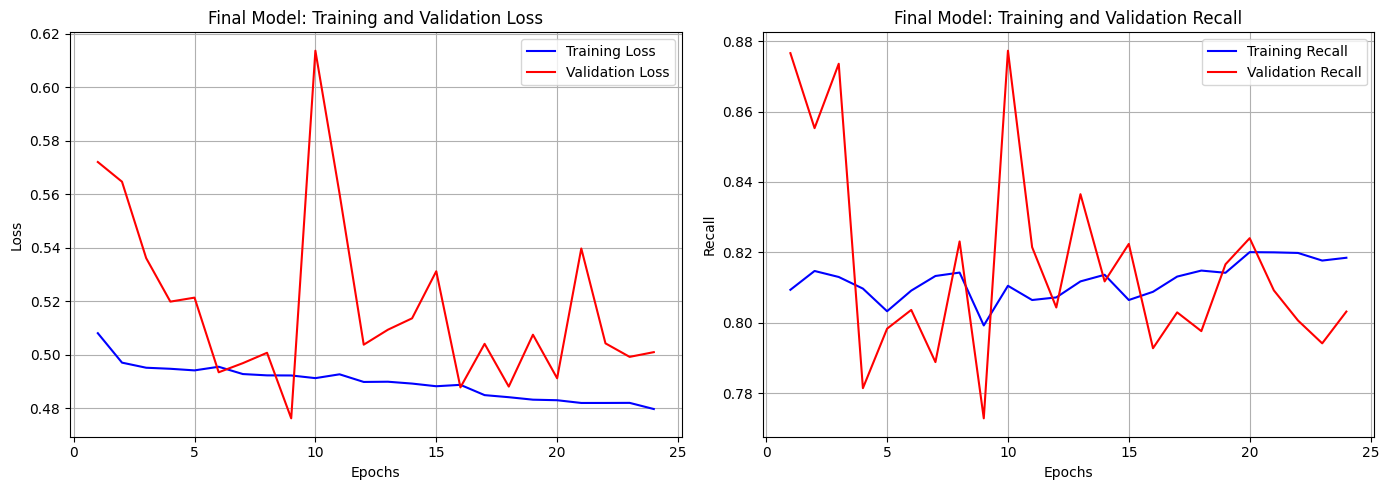

In [26]:
# ---------------------------------------------------------
# 6. EVALUATION: History Curves
# ---------------------------------------------------------
def plot_final_performance(history):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    rec = history.history["recall"]
    val_rec = history.history["val_recall"]
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(14, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, "b", label="Training Loss")
    plt.plot(epochs, val_loss, "r", label="Validation Loss")
    plt.title("Final Model: Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Recall Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, rec, "b", label="Training Recall")
    plt.plot(epochs, val_rec, "r", label="Validation Recall")
    plt.title("Final Model: Training and Validation Recall")
    plt.xlabel("Epochs")
    plt.ylabel("Recall")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_final_performance(final_history)

In [27]:
# ---------------------------------------------------------
# 7. FINAL TEST SET LEADERBOARD
# ---------------------------------------------------------
# 1. ANN Predictions
nn_probs = final_model.predict(X_test_nn, verbose=0).flatten()
nn_preds = (nn_probs > 0.5).astype(int)

# 2. LightGBM Predictions (Champion from ML section)
lgbm_preds = best_lgbm.predict(X_test)
lgbm_probs = best_lgbm.predict_proba(X_test)[:, 1]

# 3. Baseline Logistic Regression
log_preds = models["Logistic Regression"].predict(X_test)
log_probs = models["Logistic Regression"].predict_proba(X_test)[:, 1]

final_results = [
    {
        "Model": "Baseline LogReg",
        "Recall": recall_score(y_test, log_preds),
        "ROC-AUC": roc_auc_score(y_test, log_probs),
    },
    {
        "Model": "Tuned LightGBM",
        "Recall": recall_score(y_test, lgbm_preds),
        "ROC-AUC": roc_auc_score(y_test, lgbm_probs),
    },
    {
        "Model": "Deep Neural Network",
        "Recall": recall_score(y_test, nn_preds),
        "ROC-AUC": roc_auc_score(y_test, nn_probs),
    },
]

Final_Leaderboard = pd.DataFrame(final_results).sort_values(
    by="Recall", ascending=False
)

print("=" * 50)
print("FINAL TEST SET LEADERBOARD")
print("=" * 50)
display(Final_Leaderboard)

FINAL TEST SET LEADERBOARD


,Model,Recall,ROC-AUC
1,Tuned LightGBM,0.810411,0.833775
0,Baseline LogReg,0.774612,0.837180
2,Deep Neural Network,0.761644,0.837342


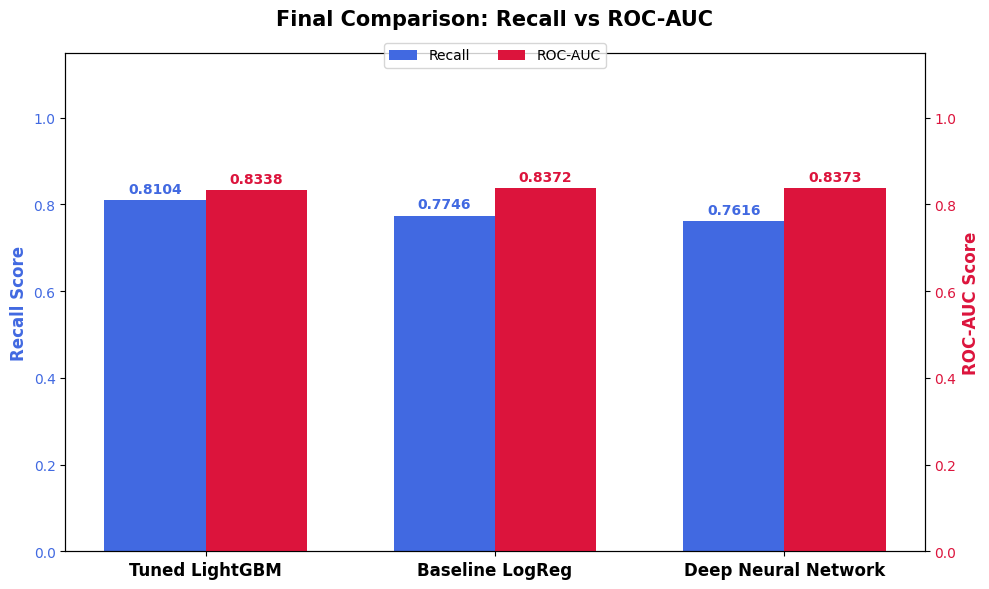

In [28]:
# ---------------------------------------------------------
# 8. VISUAL COMPARISON
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(Final_Leaderboard["Model"]))
width = 0.35

bars1 = ax1.bar(
    x - width / 2, Final_Leaderboard["Recall"], width, label="Recall", color="royalblue"
)
ax1.set_ylabel("Recall Score", color="royalblue", fontsize=12, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="royalblue")
ax1.set_ylim(0, 1.15)

ax1.set_xticks(x)
ax1.set_xticklabels(Final_Leaderboard["Model"], fontsize=12, fontweight="bold")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width / 2, Final_Leaderboard["ROC-AUC"], width, label="ROC-AUC", color="crimson"
)
ax2.set_ylabel("ROC-AUC Score", color="crimson", fontsize=12, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, 1.15)

# Add value labels
for bar in bars1:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{yval:.4f}",
        ha="center",
        va="bottom",
        color="royalblue",
        fontweight="bold",
    )

for bar in bars2:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{yval:.4f}",
        ha="center",
        va="bottom",
        color="crimson",
        fontweight="bold",
    )

plt.title("Final Comparison: Recall vs ROC-AUC", fontsize=15, pad=20, fontweight="bold")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=2, frameon=True)
plt.tight_layout()
plt.show()

## Conclusion

- Tuned LightGBM performs the best here with a Recall of 81% & ROC-AUC of 83%.

In [29]:
best_lgbm

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('engineer', ...), ('col_trans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or es